In [3]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
df_sales = pd.read_csv(r"C:\Users\khush\Downloads\Walmart.csv",on_bad_lines='skip')
df_reviews = pd.read_csv(r"C:\Users\khush\Downloads\Womens Clothing E-Commerce Reviews.csv.zip",on_bad_lines='skip')
(X_train_cnn, y_train_cnn), (X_test_cnn, y_test_cnn) = fashion_mnist.load_data()

#EDA

In [4]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df_sales.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
df_sales.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [7]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'], dayfirst=True)
df_sales['Month'] = df_sales['Date'].dt.month
df_sales['Year'] = df_sales['Date'].dt.year
df_clean = df_sales.drop(columns=['Date'])
print(df_clean.columns.tolist())

['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Select the columns that we want to scale (Input Features)
inputs = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']

# 2. Initialize the StandardScaler tool
scaler = StandardScaler()

# 3. Create a copy of the cleaned dataframe to keep the original data safe
df_ann_scaled = df_clean.copy()

# 4. Fit and transform the input numbers to make them uniform
df_ann_scaled[inputs] = scaler.fit_transform(df_clean[inputs])

print("✅ Feature scaling completed successfully!")
df_ann_scaled.head(3) # Show the first 3 rows of scaled data


✅ Feature scaling completed successfully!


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,-1.693979,1643690.90,-0.274204,-0.995136,-1.713800,1.004175,0.056964,-1.373525,-1.210899
1,-1.693979,1641957.44,3.646917,-1.201170,-1.766089,1.007880,0.056964,-1.373525,-1.210899
2,-1.693979,1611968.17,-0.274204,-1.124178,-1.840166,1.009074,0.056964,-1.373525,-1.210899


In [9]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Separate input features (X) and target variable (y)
X = df_ann_scaled[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']]
y = df_ann_scaled['Weekly_Sales']

# 2. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create the ANN Architecture (Structure)
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Hidden Layer 1 (64 neurons)
    Dense(32, activation='relu'),                               # Hidden Layer 2 (32 neurons)
    Dense(1)                                                    # Output Layer (1 neuron for sales value)
])

# 4. Compile the model (Define loss and optimizer)
ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 5. Train the model (Only 15 epochs to keep it fast on your HP laptop)
print("🚀 ANN Sales Prediction Model Training Started...\n")
history = ann_model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.1)

C:\Users\khush\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🚀 ANN Sales Prediction Model Training Started...

Epoch 1/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1406452498432.0000 - mae: 1043733.5000 - val_loss: 1437095428096.0000 - val_mae: 1056278.3750
Epoch 2/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1406280138752.0000 - mae: 1043652.5000 - val_loss: 1436731703296.0000 - val_mae: 1056113.5000
Epoch 3/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1405579558912.0000 - mae: 1043331.1250 - val_loss: 1435646427136.0000 - val_mae: 1055626.2500
Epoch 4/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1403975892992.0000 - mae: 1042589.8125 - val_loss: 1433503924224.0000 - val_mae: 1054670.3750
Epoch 5/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1401133465600.0000 - mae: 1041290.7500 - val_loss: 1430006530048.0000 - val_mae: 1053114.2500
Epoch 6/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1396790657024.0000 - mae: 1039303.5000 - val_loss: 1424917790720.0000 - val_mae: 1050853.1250
Epoch 7/15
145/145 ━━━━━━━

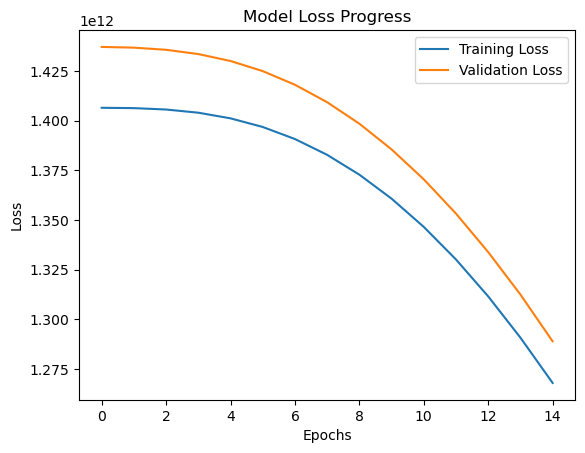

In [10]:
import matplotlib.pyplot as plt

# Plot the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [11]:
# 1. Evaluate the model on unseen Test Data
test_loss, test_mae = ann_model.evaluate(X_test, y_test, verbose=0)
print(f"📊 Test Mean Absolute Error (MAE): {test_mae:.2f}")

# 2. Save the trained model to a file
ann_model.save('ann_sales_model.keras')
print("💾 Success! Your ANN model is saved as 'ann_sales_model.h5'")


📊 Test Mean Absolute Error (MAE): 984378.56
💾 Success! Your ANN model is saved as 'ann_sales_model.h5'


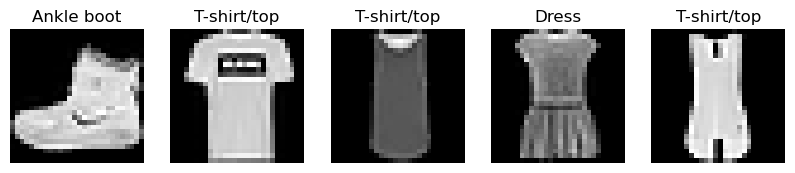

In [12]:
import matplotlib.pyplot as plt

# 1. Define the names of the 10 clothing categories in Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Plot the first 5 images from the training dataset
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Display the image (Fashion MNIST images are grayscale, so we use cmap='gray')
    plt.imshow(X_train_cnn[i].reshape(28, 28), cmap='gray')
    # Show the correct label of the clothing item above the image
    plt.title(class_names[y_train_cnn[i]])
    plt.axis('off') # Hide the graph axis for a clean look

plt.show()


In [13]:
# 1. Clean the image data by scaling pixels between 0 and 1
# This reduces the number sizes from 0-255 to 0-1 
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

# 2. Reshape the data into a 4D box format that CNN model expects:
# (Total Images, Height, Width, Colors) -> here 1 means Black & White
X_train_cnn = X_train_cnn.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_cnn.reshape(-1, 28, 28, 1)

print(" CNN Data Cleaning and Reshaping completed successfully!")
print(f"New Training Shape: {X_train_cnn.shape}")

 CNN Data Cleaning and Reshaping completed successfully!
New Training Shape: (60000, 28, 28, 1)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

print("🧱 Creating CNN Model Architecture...")

# 1. Define the CNN Architecture
cnn_model = Sequential([
    # First Layer: Convolutional layer to extract features (32 filters, 3x3 size)
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    
    # Second Layer: Max Pooling to shrink the image and capture main features
    MaxPooling2D((2, 2)),
    
    # Third Layer: Flatten 2D image pixels into a 1D single line array
    Flatten(),
    
    # Fourth Layer: Hidden Dense layer (64 neurons) to process the data
    Dense(64, activation='relu'),
    
    # Final Layer: Output layer with 10 neurons (Since there are 10 clothing types)
    Dense(10, activation='softmax')
])

# 2. Compile the CNN model (Define optimizer, loss, and metrics)
cnn_model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

print("CNN Model Created and Compiled successfully!")

# 3. Start the training process
print(" CNN Fashion Image Model Training Started...\n")
cnn_history = cnn_model.fit(X_train_cnn, y_train_cnn, 
                            epochs=10, 
                            batch_size=64, 
                            validation_split=0.1)

print(" Congratulations! Phase 2 (CNN) is complete. The image model is successfully trained!")


🧱 Creating CNN Model Architecture...
CNN Model Created and Compiled successfully!
 CNN Fashion Image Model Training Started...



C:\Users\khush\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8392 - loss: 0.4520 - val_accuracy: 0.8820 - val_loss: 0.3342
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8930 - loss: 0.3058 - val_accuracy: 0.8917 - val_loss: 0.3028
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9068 - loss: 0.2613 - val_accuracy: 0.9043 - val_loss: 0.2717
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9169 - loss: 0.2309 - val_accuracy: 0.8985 - val_loss: 0.2788
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9246 - loss: 0.2077 - val_accuracy: 0.9152 - val_loss: 0.2423
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9312 - loss: 0.1872 - val_accuracy: 0.9130 - val_loss: 0.2463
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9384 - loss: 0.1700 - val_accuracy: 0.9112 - val_loss: 0.2502
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9441 - loss: 0.1525 - 

In [15]:
# 1. Evaluate the CNN model on the unseen Test Dataset
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"📊 CNN Test Accuracy: {test_acc_cnn * 100:.2f}%")

# 2. Save the trained CNN model using the latest Keras native format
cnn_model.save('cnn_product_model.keras')
print("Success! CNN model is saved as 'cnn_product_model.keras'")


📊 CNN Test Accuracy: 90.68%
Success! CNN model is saved as 'cnn_product_model.keras'


In [16]:
df_reviews.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [17]:
df_reviews.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [18]:
#Create a smaller dataframe containing only 'Review Text' and 'Rating'
df_rnn = df_reviews[['Review Text', 'Rating']].copy()


In [19]:
# Drop the 845 rows where 'Review Text' is missing (Null)
df_rnn = df_rnn.dropna(subset=['Review Text'])


In [20]:
print(df_rnn.isnull().sum())

Review Text    0
Rating         0
dtype: int64


In [22]:
import numpy as np
# Create binary labels: 1 for Positive (Rating > 3) and 0 for Negative (Rating <= 3)
df_rnn['Label'] = np.where(df_rnn['Rating'] > 3, 1, 0)

C:\Users\khush\AppData\Local\Temp\ipykernel_10920\981157899.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rnn['Label'] = np.where(df_rnn['Rating'] > 3, 1, 0)


In [25]:
df_rnn[['Review Text', 'Label']].head(3)

,Review Text,Label
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0


In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Extract only the text sentences and target labels
reviews_list = df_rnn['Review Text'].astype(str).values
y_rnn = df_rnn['Label'].values

In [27]:
# Create a "Word-to-Number" dictionary (Keeping top 5000 words)
# <OOV> means any completely new word found later will be given a default number
my_tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")


In [28]:
# Feed all English reviews into the tokenizer to learn the words
my_tokenizer.fit_on_texts(reviews_list)


In [29]:
#Convert the actual English sentences into lists of numbers
all_sequences = my_tokenizer.texts_to_sequences(reviews_list)


In [30]:
print("Original Text:", reviews_list[0])
print("Numbered Sequence:", all_sequences[0])


Original Text: Absolutely wonderful - silky and sexy and comfortable
Numbered Sequence: [254, 533, 918, 4, 663, 4, 69]


In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 5. Fix the length of each review to exactly 50 words
# Shorter reviews will get '0' added at the end ('post')
# Longer reviews will be cut down to 50 words from the end ('post')
X_rnn_final = pad_sequences(all_sequences, maxlen=50, padding='post', truncating='post')

print(" All review lengths are now exactly 50 words!")
print("Final Input Array Shape:", X_rnn_final.shape)
print("\nFirst clean numeric review:\n", X_rnn_final[0])

 All review lengths are now exactly 50 words!
Final Input Array Shape: (22641, 50)

First clean numeric review:
 [254 533 918   4 663   4  69   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [32]:

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# 1. Split the text data into Training (80%) and Testing (20%) sets
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(X_rnn_final, y_rnn, test_size=0.2, random_state=42)

# 2. Create the RNN/LSTM Architecture
rnn_model = Sequential([
    # Layer 1: Embedding layer to convert word numbers into meaningful vectors
    Embedding(input_dim=5000, output_dim=32, input_length=50),
    
    # Layer 2: LSTM layer with memory to understand the order of words
    LSTM(32, dropout=0.2),
    
    # Layer 3: Output layer with 1 neuron and sigmoid for Binary Classification (0 or 1)
    Dense(1, activation='sigmoid')
])

C:\Users\khush\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
# Compile the model
rnn_model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
print(" RNN/LSTM Model Created successfully! Starting training...")

 RNN/LSTM Model Created successfully! Starting training...


In [34]:
# Train the model (Only 5 epochs to keep it fast and safe for your laptop)
rnn_history = rnn_model.fit(X_train_rnn, y_train_rnn, 
                            epochs=5, 
                            batch_size=64, 
                            validation_split=0.1)

print("RNN is complete. The text model is successfully trained!")


Epoch 1/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8014 - loss: 0.4627 - val_accuracy: 0.8366 - val_loss: 0.3720
Epoch 2/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8629 - loss: 0.3257 - val_accuracy: 0.8322 - val_loss: 0.3642
Epoch 3/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8873 - loss: 0.2832 - val_accuracy: 0.8526 - val_loss: 0.3435
Epoch 4/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9010 - loss: 0.2529 - val_accuracy: 0.8510 - val_loss: 0.3501
Epoch 5/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9117 - loss: 0.2285 - val_accuracy: 0.8526 - val_loss: 0.3550
RNN is complete. The text model is successfully trained!


In [37]:
# 1. Evaluate the RNN model on the unseen Test Dataset
test_loss_rnn, test_acc_rnn = rnn_model.evaluate(X_test_rnn, y_test_rnn, verbose=0)
print(f" RNN Final Test Accuracy: {test_acc_rnn * 100:.2f}%")

# 2. Save the trained RNN model using the latest Keras native format
rnn_model.save('rnn_sentiment_model.keras')
print(" Success! Your RNN model is saved as 'rnn_sentiment_model.keras'")


 RNN Final Test Accuracy: 86.09%
 Success! Your RNN model is saved as 'rnn_sentiment_model.keras'


In [38]:
import pickle

# 1. Create a file named 'tokenizer.pickle' and pack our tokenizer inside it
with open('tokenizer.pickle', 'wb') as file:
    pickle.dump(my_tokenizer, file)

print("Success! Tokenizer file is now saved.")


Success! Tokenizer file is now saved.
